# Imports

In [1]:
import os
import copy
import warnings
import itertools
import datetime as dt
import pandas as pd
import numpy as np
import random # Usado para random.sample e random.shuffle
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
from dataclasses import dataclass, field
from typing import List, Dict, Optional
from scipy.stats import norm, skew, kurtosis, truncnorm # Importar diretamente as funções
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from scipy.optimize import curve_fit
from statsmodels.graphics.gofplots import qqplot
from multiprocessing import Pool
import random
import traceback # Importar para printar o traceback em caso de erro

# Importar nas classes quando usar função standalone

warnings.filterwarnings("ignore")

In [2]:
!git clone https://github.com/gilbertogilfgp/Mercado-Artificial-Fiis.git
%cd /content/Mercado-Artificial-Fiis

import sys
sys.path.append('/content/Mercado-Artificial-Fiis')

!pip install numpy pandas matplotlib scipy statsmodels yfinance seaborn

from src.simulacao import simular_mercado_e_plotar

Cloning into 'Mercado-Artificial-Fiis'...
remote: Enumerating objects: 199, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 199 (delta 1), reused 0 (delta 0), pack-reused 193 (from 2)
Receiving objects: 100% (199/199), 12.72 MiB | 11.30 MiB/s, done.
Resolving deltas: 100% (100/100), done.
/content/Mercado-Artificial-Fiis


In [3]:
from src.simulacao import simular_mercado_e_plotar, plotar_resultado, SIM_PARAMS

In [4]:
from src.agentes import Agente, gerar_literacia_financeira
from src.ativos import FII, Imovel
from src.mercado import Mercado, BancoCentral, Midia

In [5]:
parametros_sistema = pd.read_csv('/content/Mercado-Artificial-Fiis/notebooks/dados/parametros_sistema_calibrados.csv').to_numpy()[0]

parametros_sistema

array([0.84822756, 0.69540723, 0.87855894, 0.15595803, 0.07548527])

# Experimento

In [6]:
import os, sys, types, copy, time, warnings, pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from joblib import Parallel, delayed
from google.colab import drive

warnings.filterwarnings('ignore')

# ── Setup ─────────────────────────────────────────────────────
os.chdir('/content/Mercado-Artificial-Fiis')

src_package = types.ModuleType('src')
src_package.__path__ = ['/content/Mercado-Artificial-Fiis/src']
src_package.__package__ = 'src'
sys.modules['src'] = src_package

for mod in list(sys.modules.keys()):
    if mod.startswith('src.'):
        del sys.modules[mod]

if '/content/Mercado-Artificial-Fiis' not in sys.path:
    sys.path.insert(0, '/content/Mercado-Artificial-Fiis')

from src.simulacao import simular_mercado_e_plotar, SIM_PARAMS
drive.mount('/content/drive', force_remount=False)

OUT_DIR = '/content/drive/MyDrive/tese_fii/choques_macro'
FIG_DIR = f'{OUT_DIR}/figures'
os.makedirs(FIG_DIR, exist_ok=True)

Mounted at /content/drive


In [7]:
# ── Configurações ─────────────────────────────────────────────
THETA_STAR = parametros_sistema
DIA_CHOQUE = 41
T_TOTAL    = 81
VOL_JANELA = 20
N_REP      = 10
N_JOBS     = 2

# ── Cenários ──────────────────────────────────────────────────
CENARIOS = [
    dict(inflacao=0.040, premio=0.050, label='Forte positivo\n(infl −3pp, prêmio −3pp)',  cor='#006d2c'),
    dict(inflacao=0.055, premio=0.060, label='Moderado positivo\n(infl −1.5pp, prêmio −2pp)', cor='#31a354'),
    dict(inflacao=0.065, premio=0.070, label='Leve positivo\n(infl −0.5pp, prêmio −1pp)',  cor='#74c476'),
    dict(inflacao=0.075, premio=0.090, label='Leve negativo\n(infl +0.5pp, prêmio +1pp)',  cor='#fdae6b'),
    dict(inflacao=0.085, premio=0.100, label='Moderado negativo\n(infl +1.5pp, prêmio +2pp)', cor='#e6550d'),
    dict(inflacao=0.100, premio=0.110, label='Forte negativo\n(infl +3pp, prêmio +3pp)',   cor='#bd0026'),
]

# ── Persistência ──────────────────────────────────────────────
def salvar(obj, nome):
    path = f'{OUT_DIR}/{nome}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'  ✓ Salvo: {path}')

def carregar(nome):
    path = f'{OUT_DIR}/{nome}.pkl'
    if os.path.exists(path):
        with open(path, 'rb') as f:
            obj = pickle.load(f)
        print(f'  ✓ Carregado: {path}')
        return obj
    return None

In [8]:
# ── Simuladores ───────────────────────────────────────────────
def run_cenario(inflacao, premio, seed):
    np.random.seed(seed)

    params = copy.deepcopy(SIM_PARAMS)
    params["prob_choque_diario"] = 0.0
    params["choques"] = [
        {
            "categoria": "macro",
            "dia":       DIA_CHOQUE,
            "inflacao":  inflacao,
            "premio":    premio,
        }
    ]

    r = simular_mercado_e_plotar(
        parametros_sistema=THETA_STAR,
        num_dias=T_TOTAL,
        sim_params=params,
        imprimir=False,
    )
    return (np.array(r[0])[-T_TOTAL:],
            np.array(r[1])[-(T_TOTAL - 1):],
            np.array(r[4], dtype=float))


def run_controle(seed):
    np.random.seed(seed)

    params = copy.deepcopy(SIM_PARAMS)
    params["prob_choque_diario"] = 0.0
    params["choques"] = []

    r = simular_mercado_e_plotar(
        parametros_sistema=THETA_STAR,
        num_dias=T_TOTAL,
        sim_params=params,
        imprimir=False,
    )
    return (np.array(r[0])[-T_TOTAL:],
            np.array(r[1])[-(T_TOTAL - 1):],
            np.array(r[4], dtype=float))

# ── Vol rolante ───────────────────────────────────────────────
def vol_rolante(retornos, janela=VOL_JANELA):
    vol = np.full(len(retornos), np.nan)
    for t in range(janela - 1, len(retornos)):
        vol[t] = np.std(retornos[t - janela + 1:t + 1])
    return vol

# ── Agregar ───────────────────────────────────────────────────
def agregar(lista_p, lista_r, lista_s):
    precos_norm = []
    for p in lista_p:
        if len(p) >= DIA_CHOQUE:
            ref = p[DIA_CHOQUE - 2]
            if ref > 0:
                precos_norm.append(p / ref)
    vols  = [vol_rolante(r) for r in lista_r if len(r) >= VOL_JANELA]
    sents = [s for s in lista_s if len(s) > 0]

    def stats(mat_list):
        mat = np.array(mat_list)
        m   = np.nanmean(mat, axis=0)
        se  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])
        return m, m - 1.96 * se, m + 1.96 * se

    p_ = stats(precos_norm) if precos_norm else (None,) * 3
    v_ = stats(vols)        if vols        else (None,) * 3
    s_ = stats(sents)       if sents       else (None,) * 3
    return (*p_, *v_, *s_)

# ── Rodar cenário ─────────────────────────────────────────────
def rodar_cenario_unico(c, prefixo):
    seeds = [
        abs(hash(f'{prefixo}_{c["inflacao"]}_{c["premio"]}_{r}')) % (2**31)
        for r in range(N_REP)
    ]
    res = Parallel(n_jobs=N_JOBS)(
        delayed(run_cenario)(c['inflacao'], c['premio'], s)
        for s in seeds
    )
    agg = agregar([r[0] for r in res],
                  [r[1] for r in res],
                  [r[2] for r in res])
    print(f'  ✓ {c["label"].replace(chr(10), " ")}')
    return (agg, c)

# ── Plot ──────────────────────────────────────────────────────
def plot_experimento(cenarios, controle_agg, titulo, fname):
    dias_p = np.arange(1, T_TOTAL + 1)
    dias_r = np.arange(1, T_TOTAL)

    fig = plt.figure(figsize=(16, 12))
    gs  = gridspec.GridSpec(3, 1, hspace=0.45)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    ax3 = fig.add_subplot(gs[2])

    cp, cp_lo, cp_hi, cv, cv_lo, cv_hi, cs, cs_lo, cs_hi = controle_agg

    if cp is not None:
        ax1.fill_between(dias_p, cp_lo, cp_hi, color='gray', alpha=0.15, label='Controle (IC 95%)')
        ax1.plot(dias_p, cp, color='gray', lw=1.2, ls='--', alpha=0.6)
    if cv is not None:
        ax2.fill_between(dias_r, cv_lo, cv_hi, color='gray', alpha=0.15)
        ax2.plot(dias_r, cv, color='gray', lw=1.2, ls='--', alpha=0.6)
    if cs is not None:
        ax3.fill_between(np.arange(len(cs)), cs_lo, cs_hi, color='gray', alpha=0.15)
        ax3.plot(np.arange(len(cs)), cs, color='gray', lw=1.2, ls='--', alpha=0.6)

    for (agg, meta) in cenarios:
        p, p_lo, p_hi, v, v_lo, v_hi, s, s_lo, s_hi = agg
        cor   = meta['cor']
        label = meta['label'].replace('\n', ' ')
        if p is not None:
            ax1.fill_between(dias_p, p_lo, p_hi, color=cor, alpha=0.10)
            ax1.plot(dias_p, p, color=cor, lw=2, label=label)
        if v is not None:
            ax2.fill_between(dias_r, v_lo, v_hi, color=cor, alpha=0.10)
            ax2.plot(dias_r, v, color=cor, lw=2, label=label)
        if s is not None:
            ax3.fill_between(np.arange(len(s)), s_lo, s_hi, color=cor, alpha=0.10)
            ax3.plot(np.arange(len(s)), s, color=cor, lw=2, label=label)

    for ax in [ax1, ax2, ax3]:
        ax.axvline(DIA_CHOQUE, color='red', lw=1.5, ls='--', alpha=0.7,
                   label='Choque' if ax == ax1 else '')
        ax.grid(True, alpha=0.2, ls=':')

    ax1.axhline(1.0, color='black', lw=0.8, ls=':', alpha=0.5)
    ax3.axhline(0.0, color='black', lw=0.8, ls=':', alpha=0.5)
    ax1.set_ylabel('Preço normalizado\n(P / P anterior ao choque)', fontsize=10)
    ax2.set_ylabel(f'Volatilidade rolante\n({VOL_JANELA} dias)', fontsize=10)
    ax3.set_ylabel('Sentimento médio\nda população', fontsize=10)
    ax3.set_xlabel('Dia de simulação', fontsize=10)
    ax3.set_ylim(-1.1, 1.1)
    ax1.legend(fontsize=7, loc='lower left', ncol=2)
    ax2.legend(fontsize=7, loc='upper left', ncol=2)
    fig.suptitle(titulo, fontsize=13, fontweight='bold', y=1.01)

    path = f'{FIG_DIR}/{fname}'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'  ✓ Figura: {path}')

print('✓ Funções carregadas')
print(f'  OUT_DIR  : {OUT_DIR}')
print(f'  N_REP={N_REP} | N_JOBS={N_JOBS} | T={T_TOTAL} | Choque dia {DIA_CHOQUE}')
print()
print(f'  {"Cenário":<35} {"Inflação":>10} {"Prêmio":>10}')
print(f'  {"-"*57}')
for c in CENARIOS:
    print(f'  {c["label"].replace(chr(10)," "):<35} {c["inflacao"]:>10.3f} {c["premio"]:>10.3f}')

✓ Funções carregadas
  OUT_DIR  : /content/drive/MyDrive/tese_fii/choques_macro
  N_REP=10 | N_JOBS=2 | T=81 | Choque dia 41

  Cenário                               Inflação     Prêmio
  ---------------------------------------------------------
  Forte positivo (infl −3pp, prêmio −3pp)      0.040      0.050
  Moderado positivo (infl −1.5pp, prêmio −2pp)      0.055      0.060
  Leve positivo (infl −0.5pp, prêmio −1pp)      0.065      0.070
  Leve negativo (infl +0.5pp, prêmio +1pp)      0.075      0.090
  Moderado negativo (infl +1.5pp, prêmio +2pp)      0.085      0.100
  Forte negativo (infl +3pp, prêmio +3pp)      0.100      0.110


In [9]:
# ══════════════════════════════════════════════════════════════
# CONTROLE
# ══════════════════════════════════════════════════════════════
print('\n── Controle ──────────────────────────────────────────')
controle_agg = carregar('controle_agg')

if controle_agg is None:
    print('Rodando controle...')
    t0    = time.time()
    seeds = [abs(hash(f'ctrl_macro_{r}')) % (2**31) for r in range(N_REP)]
    res   = Parallel(n_jobs=N_JOBS)(
        delayed(run_controle)(s) for s in seeds
    )
    controle_agg = agregar([r[0] for r in res],
                           [r[1] for r in res],
                           [r[2] for r in res])
    salvar(controle_agg, 'controle_agg')
    print(f'  Tempo: {(time.time() - t0) / 60:.1f} min')


── Controle ──────────────────────────────────────────
  ✓ Carregado: /content/drive/MyDrive/tese_fii/choques_macro/controle_agg.pkl



── Experimento — Choque Macro ────────────────────────
  ✓ Carregado: /content/drive/MyDrive/tese_fii/choques_macro/exp_macro.pkl


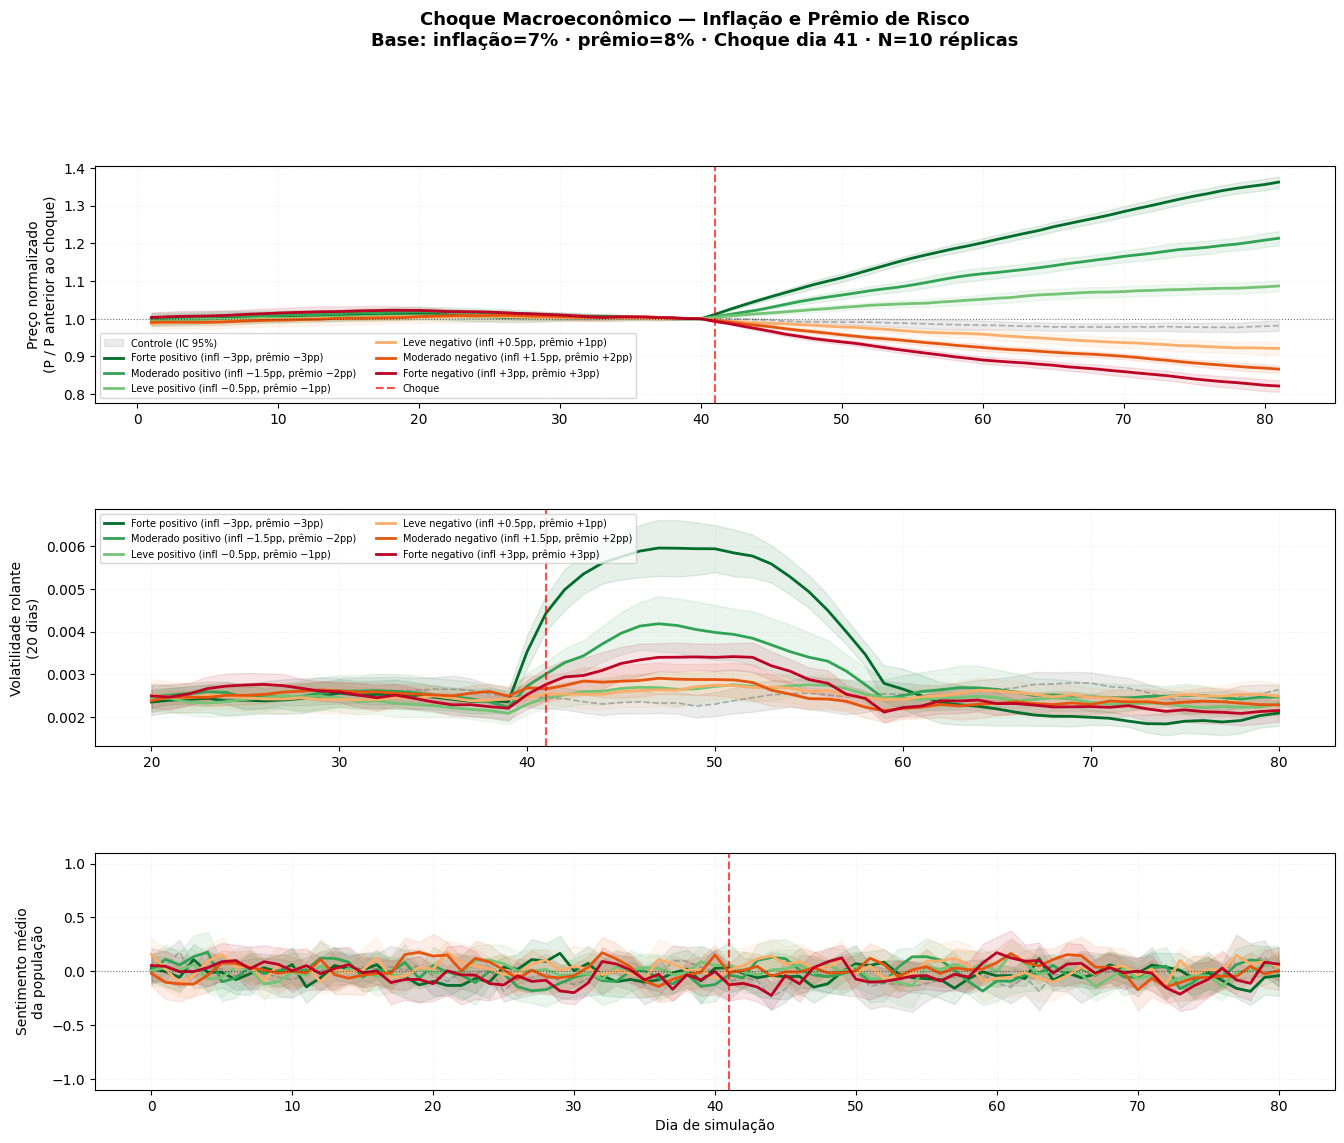

  ✓ Figura: /content/drive/MyDrive/tese_fii/choques_macro/figures/exp_macro.png

Cenário                             Queda/Alta (%) P̄ final (%)   Pico vol Dias vol>base  Sent. mín
-------------------------------------------------------------------------------------------------
Forte positivo (infl −3pp, prêmio −3pp)          36.24        29.46    0.00596            17    -0.1866
Moderado positivo (infl −1.5pp, prêmio −2pp)          21.34        17.06    0.00419            16    -0.1844
Leve positivo (infl −0.5pp, prêmio −1pp)           8.70         7.37    0.00276             0    -0.1396
Leve negativo (infl +0.5pp, prêmio +1pp)          -7.87        -6.50    0.00274             0    -0.1204
Moderado negativo (infl +1.5pp, prêmio +2pp)         -13.34       -10.64    0.00291             9    -0.1716
Forte negativo (infl +3pp, prêmio +3pp)         -17.83       -14.63    0.00341            14    -0.2242


In [10]:
# ══════════════════════════════════════════════════════════════
# EXPERIMENTO — CHOQUE MACRO
# ══════════════════════════════════════════════════════════════
print('\n── Experimento — Choque Macro ────────────────────────')
exp_macro = carregar('exp_macro')

if exp_macro is None:
    t0        = time.time()
    exp_macro = []
    for c in CENARIOS:
        nome_cache = f'macro_infl{str(c["inflacao"]).replace(".", "_")}'
        resultado  = carregar(nome_cache)
        if resultado is None:
            resultado = rodar_cenario_unico(c, 'macro')
            salvar(resultado, nome_cache)
        exp_macro.append(resultado)
    salvar(exp_macro, 'exp_macro')
    print(f'  Tempo total: {(time.time() - t0) / 60:.1f} min')

plot_experimento(
    exp_macro, controle_agg,
    titulo=('Choque Macroeconômico — Inflação e Prêmio de Risco\n'
            f'Base: inflação=7% · prêmio=8% · Choque dia {DIA_CHOQUE} · N={N_REP} réplicas'),
    fname='exp_macro.png',
)

# ── Tabela resumo ─────────────────────────────────────────────
cv_ctrl  = controle_agg[3]
vol_base = cv_ctrl[20:DIA_CHOQUE]
vol_base = vol_base[~np.isnan(vol_base)].mean()
limiar   = vol_base * 1.10

print(f'\n{"Cenário":<35} {"Queda/Alta (%)":>14} {"P̄ final (%)":>12} '
      f'{"Pico vol":>10} {"Dias vol>base":>13} {"Sent. mín":>10}')
print('-' * 97)

for (agg, meta) in exp_macro:
    p, v, s   = agg[0], agg[3], agg[6]
    label     = meta['label'].replace('\n', ' ')
    if p is None: continue
    p_pos     = p[DIA_CHOQUE:]
    extremo   = (p_pos.min() - 1.0) * 100 if meta['inflacao'] > 0.07 \
                else (p_pos.max() - 1.0) * 100
    p_final   = (p[-20:].mean() - 1.0) * 100
    v_pos_c   = v[DIA_CHOQUE:][~np.isnan(v[DIA_CHOQUE:])] if v is not None else np.array([])
    pico_vol  = v_pos_c.max() if len(v_pos_c) > 0 else np.nan
    dias_vol  = int(np.sum(v_pos_c > limiar)) if len(v_pos_c) > 0 else 0
    sent_min  = s[DIA_CHOQUE:].min() if s is not None else np.nan
    print(f'{label:<35} {extremo:>14.2f} {p_final:>12.2f} '
          f'{pico_vol:>10.5f} {dias_vol:>13} {sent_min:>10.4f}')

# Estatísticas

In [11]:
# ══════════════════════════════════════════════════════════════
# APÊNDICE — Estatísticas do choque macroeconômico
# ══════════════════════════════════════════════════════════════
import numpy as np, pandas as pd

exp_macro    = carregar('exp_macro')
controle_agg = carregar('controle_agg')

DIA = DIA_CHOQUE - 1
POS = slice(DIA, None)
cp, cp_lo, cp_hi = controle_agg[0], controle_agg[1], controle_agg[2]
cv, cv_hi        = controle_agg[3], controle_agg[5]
cs, cs_hi        = controle_agg[6], controle_agg[8]
vol_base = cv[20:DIA_CHOQUE]; vol_base = vol_base[~np.isnan(vol_base)].mean()
limiar   = vol_base * 1.10
se = lambda m, hi: (hi - m) / 1.96
def arg_ext(x):
    seg = x[POS]; idx = np.where(~np.isnan(seg))[0]
    return DIA + idx[np.argmax(np.abs(seg[idx]))]

def estat(agg):
    p, p_lo, p_hi = agg[0], agg[1], agg[2]
    v, v_hi       = agg[3], agg[5]
    s, s_hi       = agg[6], agg[8]
    dev_p = p - cp; se_p = np.sqrt(se(p, p_hi)**2 + se(cp, cp_hi)**2); ip = arg_ext(dev_p)
    pfin  = np.nanmean(p[-20:] - cp[-20:]) * 100
    sig   = [t for t in range(DIA, len(p))
             if not (np.isnan(p_lo[t]) or np.isnan(cp_lo[t]))
             and (p_lo[t] > cp_hi[t] or p_hi[t] < cp_lo[t])]
    dev_s = s - cs; se_s = np.sqrt(se(s, s_hi)**2 + se(cs, cs_hi)**2); isx = arg_ext(dev_s)
    dev_v = v - cv; se_v = np.sqrt(se(v, v_hi)**2 + se(cv, cv_hi)**2); iv = arg_ext(dev_v)
    vabs  = v[POS][~np.isnan(v[POS])]
    return {
        'Preço extremo (%)' : f'{dev_p[ip]*100:+.2f} ± {1.96*se_p[ip]*100:.2f}',
        'Dia'               : ip,
        'P̄ final (%)'       : f'{pfin:+.2f}',
        'Signif. (dias)'    : f'{sig[0]}–{sig[-1]} ({len(sig)})' if sig else '—',
        'Sentimento'        : f'{dev_s[isx]:+.4f} ± {1.96*se_s[isx]:.4f}',
        'Vol. pico vs ctrl' : f'{dev_v[iv]:+.5f} ± {1.96*se_v[iv]:.5f}',
        'Dias vol>base'     : int(np.sum(vabs > limiar)),
    }

pd.set_option('display.max_columns', None); pd.set_option('display.width', 220)
df = pd.DataFrame({m['label'].replace('\n', ' '): estat(a) for (a, m) in exp_macro}).T
print('===== Choque macroeconômico ====='); print(df.to_string())

# Assimetria de magnitude do preço (forte positivo vs forte negativo)
def pico(agg):
    dev = agg[0] - cp; i = arg_ext(dev)
    se_p = np.sqrt(se(agg[0], agg[2])**2 + se(cp, cp_hi)**2)
    return dev[i]*100, 1.96*se_p[i]*100
R = {m['label'].split('\n')[0]: a for (a, m) in exp_macro}
pp, ep = pico(R['Forte positivo']); pn, en = pico(R['Forte negativo'])
dif = abs(pp) - abs(pn); ic = np.sqrt(ep**2 + en**2)
print(f'\nAssimetria preço |forte pos| - |forte neg| = {dif:+.2f} ± {ic:.2f} pp '
      f'(razão {abs(pp)/abs(pn):.2f}) -> {"SIGNIFICATIVA" if abs(dif) > ic else "dentro da margem"}')

  ✓ Carregado: /content/drive/MyDrive/tese_fii/choques_macro/exp_macro.pkl
  ✓ Carregado: /content/drive/MyDrive/tese_fii/choques_macro/controle_agg.pkl
===== Choque macroeconômico =====
                                             Preço extremo (%) Dia P̄ final (%) Signif. (dias)        Sentimento   Vol. pico vs ctrl Dias vol>base
Forte positivo (infl −3pp, prêmio −3pp)          +38.05 ± 2.00  80       +31.59     40–80 (41)  +0.3019 ± 0.2134  +0.00369 ± 0.00067            18
Moderado positivo (infl −1.5pp, prêmio −2pp)     +23.16 ± 2.32  80       +19.18     40–80 (41)  +0.3655 ± 0.2009  +0.00186 ± 0.00068            17
Leve positivo (infl −0.5pp, prêmio −1pp)         +10.51 ± 1.99  80        +9.49     40–80 (41)  +0.3121 ± 0.1962  -0.00045 ± 0.00033             0
Leve negativo (infl +0.5pp, prêmio +1pp)          -6.05 ± 2.18  80        -4.38     41–80 (25)  +0.3796 ± 0.2055  +0.00045 ± 0.00045             0
Moderado negativo (infl +1.5pp, prêmio +2pp)     -11.53 ± 1.63  80        -8.5